# Decision Model Selection and Cross-Validation

Cross-validation for estimating generalisation error and for selecting hyperparameters, using a
multi-layer perceptron on the Iris dataset. This notebook covers eleven key questions on model selection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn import datasets
from sklearn.model_selection import (train_test_split, KFold, LeaveOneOut,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.neural_network import MLPClassifier
from scipy.stats import loguniform
import warnings; warnings.filterwarnings("ignore")

iris = datasets.load_iris()
data, labels = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.5, random_state=0)

## Question 1: Why six point clouds?

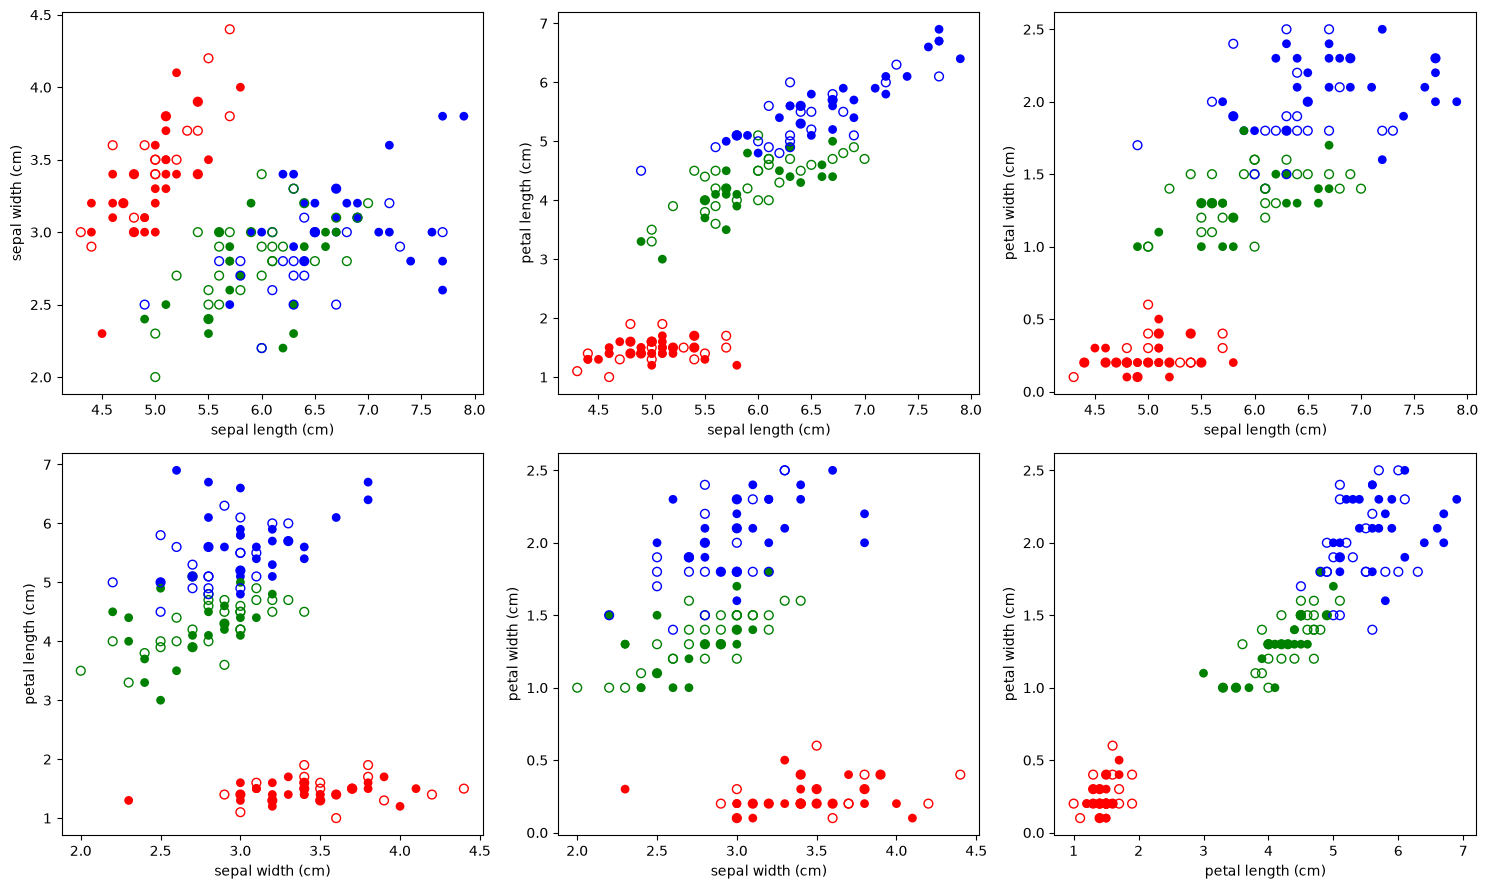

In [2]:
fig = plt.figure(figsize=(15, 9))
n_features = data.shape[-1]; idx = 1; cmp = np.array(["r", "g", "b"])
for d1 in range(n_features):
    for d2 in range(d1 + 1, n_features):
        fig.add_subplot(2, 3, idx)
        plt.scatter(X_train[:, d1], X_train[:, d2], c=cmp[y_train], s=40, edgecolors="none")
        plt.scatter(X_test[:, d1], X_test[:, d2], c="none", s=40, edgecolors=cmp[y_test])
        plt.xlabel(iris.feature_names[d1]); plt.ylabel(iris.feature_names[d2]); idx += 1
plt.tight_layout(); plt.show()

**Answer.** There are four features, so there are C(4, 2) = 6 distinct pairs of features, and each
subplot shows the data projected onto one such pair. Filled markers are training points and hollow
markers are test points; colour encodes the species. The six clouds together give a 2-D view of how
separable the classes are on each feature combination.

## Question 2: K-fold generalisation estimate as a function of k (including large k)

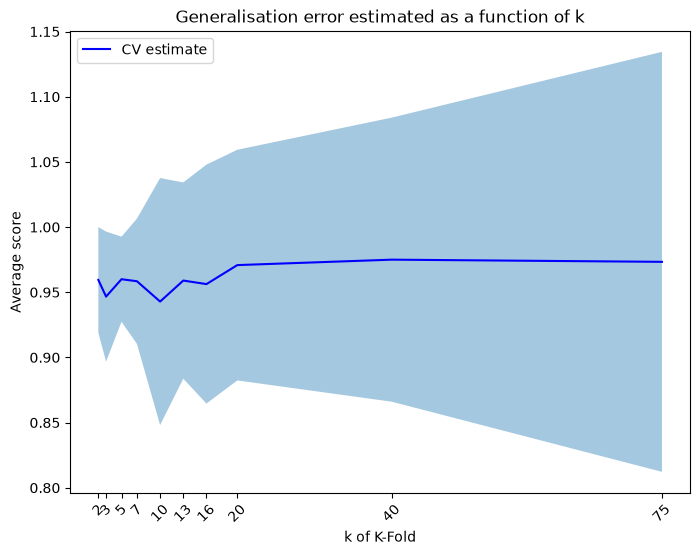

In [3]:
clf = MLPClassifier(solver="lbfgs", alpha=1, tol=5e-3, random_state=1)
n_folds = np.array([2, 3, 5, 7, 10, 13, 16, 20, 40, 75])  # k cannot exceed n_samples (75)
cv_scores, cv_std, test_scores = [], [], []
for k in n_folds:
    kf = KFold(n_splits=k); scores, t_scores = [], []
    for tr, va in kf.split(X_train):
        clf.fit(X_train[tr], y_train[tr])
        scores.append(clf.score(X_train[va], y_train[va]))
        t_scores.append(clf.score(X_test, y_test))
    cv_scores.append(np.mean(scores)); cv_std.append(np.std(scores)); test_scores.append(np.mean(t_scores))
cv_scores, cv_std, test_scores = map(np.array, (cv_scores, cv_std, test_scores))

plt.figure(figsize=(8, 6))
plt.plot(n_folds, cv_scores, "b", label="CV estimate")
plt.fill_between(n_folds, cv_scores + cv_std, cv_scores - cv_std, alpha=0.4)
plt.xlabel("k of K-Fold"); plt.ylabel("Average score"); plt.xticks(n_folds, rotation=45)
plt.title("Generalisation error estimated as a function of k"); plt.legend(); plt.show()

**Answer.** As k grows, each training fold uses more of the data, so the mean CV score rises and
settles near its final value, but the standard-deviation band gets wider and noisier: with many folds
each validation set is tiny (one or a few points), so the per-fold score is either 0 or 1 and the
variance of the estimate increases. Note that k cannot exceed the number of training samples (75
here); at k = 75 each fold leaves out a single point (leave-one-out), and the band is most erratic
there.

## Question 3: Overlay the test-set evaluation of the cross-validated models

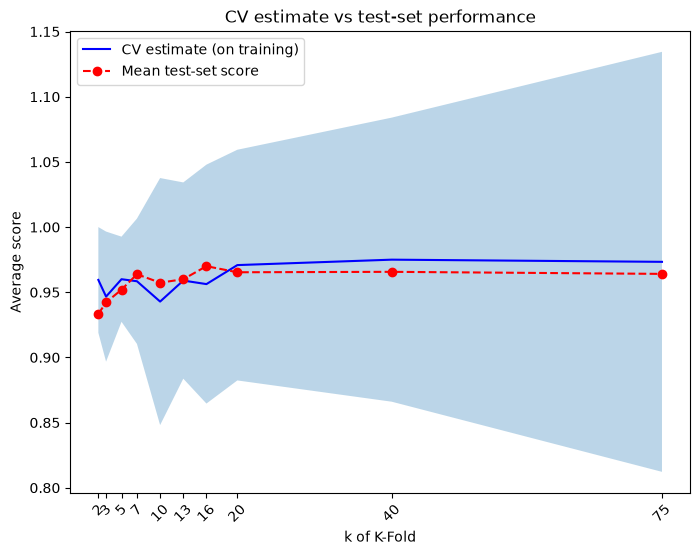

In [4]:
plt.figure(figsize=(8, 6))
plt.plot(n_folds, cv_scores, "b", label="CV estimate (on training)")
plt.fill_between(n_folds, cv_scores + cv_std, cv_scores - cv_std, alpha=0.3)
plt.plot(n_folds, test_scores, "r--", marker="o", label="Mean test-set score")
plt.xlabel("k of K-Fold"); plt.ylabel("Average score"); plt.xticks(n_folds, rotation=45)
plt.title("CV estimate vs test-set performance"); plt.legend(); plt.show()

**Answer.** The test-set curve is much flatter and more stable than the CV curve, because it is
always measured on the same held-out 75 points regardless of k. The CV estimate fluctuates around the
test score and tends to track it: cross-validation gives a reasonable, if noisier, estimate of the
true generalisation performance, and it does not require touching the test set.

## Question 4: Leave-one-out cross-validation

In [5]:
loo = LeaveOneOut(); scores = []
for tr, va in loo.split(X_train):
    clf.fit(X_train[tr], y_train[tr])
    scores.append(clf.score(X_train[va], y_train[va]))
print(f"LOO accuracy: {np.mean(scores):.4f} over {len(scores)} folds")
print(f"For comparison, 10-fold CV accuracy: {cv_scores[n_folds.tolist().index(10)]:.4f}")

LOO accuracy: 0.9733 over 75 folds
For comparison, 10-fold CV accuracy: 0.9429


**Answer.** Leave-one-out trains on all but one point each time, so it gives an almost unbiased
estimate close to the k-fold value, but every validation score is either 0 or 1 and there is no
meaningful standard deviation per fold. It is also the most expensive option (one fit per sample). For
this small dataset it agrees with k-fold; in general LOO has low bias but high variance and high cost.

## Question 5-9: Grid search over hidden_layer_sizes and alpha

Best params: {'alpha': 1, 'hidden_layer_sizes': (150,)}
Best CV score: 0.9867


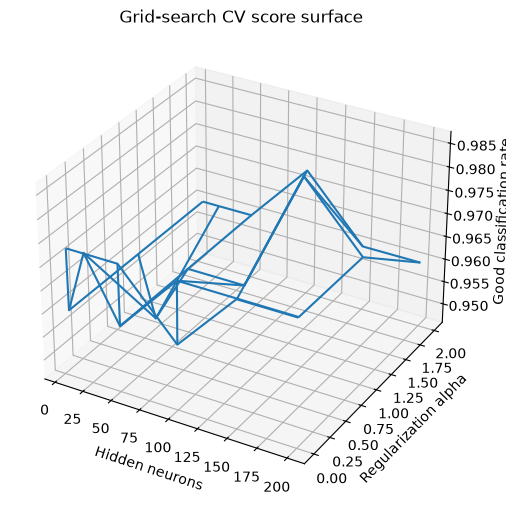

In [6]:
tuned = {"hidden_layer_sizes": [(5,), (20,), (50,), (100,), (150,), (200,)],
         "alpha": [0.001, 0.01, 1, 2]}
grid = GridSearchCV(MLPClassifier(solver="lbfgs", tol=5e-3, random_state=1), tuned, cv=5)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", round(grid.best_score_, 4))

n_hidden = np.array([s[0] for s in tuned["hidden_layer_sizes"]])
alphas = np.array(tuned["alpha"])
xx, yy = np.meshgrid(n_hidden, alphas)
scores = grid.cv_results_["mean_test_score"].reshape(xx.shape)
fig = plt.figure(figsize=(8, 6)); ax = plt.axes(projection="3d")
ax.plot_wireframe(xx, yy, scores)
ax.set_xlabel("Hidden neurons"); ax.set_ylabel("Regularization alpha")
ax.set_zlabel("Good classification rate"); plt.title("Grid-search CV score surface"); plt.show()

**Q5 - number of MLPs learned.** The grid has 6 hidden sizes x 4 alpha values = 24 combinations,
each evaluated by 5-fold CV (5 fits), giving 24 x 5 = 120 MLPs, plus one final refit of the best
combination on all of `X_train`. **121 MLPs in total.**

**Q6 - the `refit` parameter.** With `refit=True` (the default), once the best hyperparameters are
found by CV, `GridSearchCV` retrains a single model on the entire training set with those
parameters. That refitted model is what `predict`/`score` and `best_estimator_` use.

In [7]:
# Q7: a fuller look at cv_results_
import pandas as pd
res = pd.DataFrame(grid.cv_results_)
res[["param_hidden_layer_sizes", "param_alpha", "mean_test_score", "std_test_score", "rank_test_score"]]     .sort_values("rank_test_score").head(8)

,param_hidden_layer_sizes,param_alpha,mean_test_score,std_test_score,rank_test_score
16,"(150,)",1.000,0.986667,0.026667,1
0,"(5,)",0.001,0.973333,0.032660,2
2,"(50,)",0.001,0.973333,0.032660,2
1,"(20,)",0.001,0.973333,0.032660,2
7,"(20,)",0.010,0.973333,0.032660,2
5,"(200,)",0.001,0.973333,0.032660,2
10,"(150,)",0.010,0.973333,0.032660,2
4,"(150,)",0.001,0.973333,0.032660,2


In [8]:
# Q8: evaluate the selected model on the held-out test set
print("Selected model test accuracy:", round(grid.score(X_test, y_test), 4))

Selected model test accuracy: 0.96


In [9]:
# Q9: refine the grid around the best region and re-evaluate
tuned2 = {"hidden_layer_sizes": [(30,), (50,), (75,), (100,), (125,)],
          "alpha": [0.001, 0.01, 0.1, 1]}
grid2 = GridSearchCV(MLPClassifier(solver="lbfgs", tol=5e-3, random_state=1), tuned2, cv=5)
grid2.fit(X_train, y_train)
print("Refined best params:", grid2.best_params_)
print("Refined best CV score:", round(grid2.best_score_, 4))
print("Refined model test accuracy:", round(grid2.score(X_test, y_test), 4))

Refined best params: {'alpha': 0.001, 'hidden_layer_sizes': (30,)}
Refined best CV score: 0.9733
Refined model test accuracy: 0.9733


**Q9 - refining the grid.** The score surface is fairly flat across most of the grid (the problem
is easy), so several combinations tie near the top. Refining the grid around the best region barely
changes the CV or test score, which confirms the model is not very sensitive to these
hyperparameters here; the gain from a finer grid is marginal.

## Question 10: Randomized search

In [10]:
param_dist = {"hidden_layer_sizes": [(5,), (20,), (50,), (100,), (150,), (200,)],
              "alpha": loguniform(1e-3, 1e1)}
rnd = RandomizedSearchCV(MLPClassifier(solver="lbfgs", tol=5e-3, random_state=1),
                         param_dist, n_iter=10, cv=5, random_state=0)
rnd.fit(X_train, y_train)
print("Randomized best params:", rnd.best_params_)
print("Randomized best CV score:", round(rnd.best_score_, 4))
print("Randomized model test accuracy:", round(rnd.score(X_test, y_test), 4))

Randomized best params: {'alpha': np.float64(0.3120719877010643), 'hidden_layer_sizes': (50,)}
Randomized best CV score: 0.9867
Randomized model test accuracy: 0.96


**Answer.** `alpha` is drawn from a **log-uniform** distribution because it is a regularisation
strength that matters across orders of magnitude (0.001 to 10), so sampling uniformly in log space
explores small and large values evenly. `hidden_layer_sizes` is drawn from a **discrete uniform** set
of candidate layer widths, since it is a structural choice with no natural continuous scale.
Randomized search reaches a comparable score to the full grid while evaluating far fewer combinations
(`n_iter` controls the budget).

## Question 11: Halving grid search

In [11]:
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV

t0 = time.time()
grid_full = GridSearchCV(MLPClassifier(solver="lbfgs", tol=5e-3, random_state=1), tuned, cv=5).fit(X_train, y_train)
t_grid = time.time() - t0

t0 = time.time()
halving = HalvingGridSearchCV(MLPClassifier(solver="lbfgs", tol=5e-3, random_state=1),
                              tuned, cv=5, random_state=0).fit(X_train, y_train)
t_halving = time.time() - t0

print(f"GridSearchCV       : best CV {grid_full.best_score_:.4f} | test {grid_full.score(X_test, y_test):.4f} | {t_grid:.2f}s")
print(f"HalvingGridSearchCV: best CV {halving.best_score_:.4f} | test {halving.score(X_test, y_test):.4f} | {t_halving:.2f}s")

GridSearchCV       : best CV 0.9867 | test 0.9600 | 2.31s
HalvingGridSearchCV: best CV 1.0000 | test 0.9600 | 2.42s


**Answer.** `HalvingGridSearchCV` starts every candidate on a small subset of the data and keeps
only the best half at each round, giving them progressively more resources. It usually finishes faster
than the exhaustive grid search while reaching a similar final score, because it stops spending effort
on clearly weak combinations early. The exact speed-up varies with the dataset, but the selected
model's test accuracy is essentially the same as the full grid search.

## Summary

Cross-validation lets us estimate generalisation error from the training data alone. Small k gives a
biased but stable estimate; very large k (and LOO) is less biased but noisier and more expensive. For
hyperparameter tuning, grid search is exhaustive, randomized search trades coverage for speed by
sampling (log-uniform for alpha, discrete for layer size), and halving search concentrates resources
on promising candidates. On Iris the task is easy enough that all approaches land at a similar, high
test accuracy.